# Parametric PINN Training (02 layout)

This notebook reuses the structure of **02_pinn_train.ipynb** but implements the
parametric/`ParamBC` logic from the dedicated parametric notebook.  

## Setup

In [2]:
import sys
from pathlib import Path
from dataclasses import dataclass
import json
import time
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import importlib

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise RuntimeError("Could not find project root containing /src")
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))


import src.pinn
from src.utils import set_seed, get_device
from src.data import load_manifest_rows, load_case_manifest_row, ParamPINNBatch
from src.pinn import FluxConsistentLeftBoundaryMLP, LossWeights, dtheta_dxi
from src.train import train_adam, train_lbfgs, compute_losses_eval

set_seed(42)
device = get_device()
print(f"Project root: {ROOT}")
print(f"Device: {device}")

MU_TIME_SAMPLES = 15

RUN_ID = datetime.now(timezone.utc).strftime("%Y_%m_%d_%H%M")
OUTDIR = ROOT / "outputs" / "parametric" / RUN_ID
OUTDIR.mkdir(parents=True, exist_ok=True)
print(f"RUN_ID: {RUN_ID}")
print(f"OUTDIR: {OUTDIR}")


Project root: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN
Device: cpu
RUN_ID: 2026_03_17_1034
OUTDIR: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_17_1034


## Data Loading and Case Split

In [3]:
manifest = ROOT / "data" / "manifest.csv"
rows = load_manifest_rows(manifest)
if len(rows) < 2:
    raise RuntimeError("Need at least two cases for train/held-out split.")

# deterministic split; keep final 20% as held-out
rows_sorted = sorted(rows, key=lambda r: r["case_id"])
n_val_cases = max(1, int(round(0.2 * len(rows_sorted))))
val_rows = rows_sorted[-n_val_cases:]
train_rows = rows_sorted[:-n_val_cases]

if len(train_rows) == 0:
    raise RuntimeError("Split produced no training cases.")

print("Train cases:", [r["case_id"] for r in train_rows])
print("Held-out cases:", [r["case_id"] for r in val_rows])

Train cases: ['const_10000', 'const_10000_Tleft_280', 'const_10000_Tleft_300', 'const_10000_Tleft_310', 'const_12000', 'const_14000', 'const_15000', 'const_20000', 'const_5000', 'const_6000', 'offset_sine_1', 'sine_A10000_T100', 'sine_A10000_T50', 'sine_A12500_T125', 'sine_A12500_T25', 'sine_A12500_T75', 'sine_A5000_T100']
Held-out cases: ['sine_A5000_T50', 'sine_A7500_T125', 'sine_A7500_T25', 'sine_A7500_T75']


## Data Preprocessing and Parametric Batch

In [4]:
def compute_mu_stats(cases):
    eps = 1e-8
    all_mu = np.array([c["mu_raw"] for c in cases])
    mu_min = all_mu.min(axis=0)
    mu_max = all_mu.max(axis=0)
    return {
        "mu_min": mu_min,
        "mu_max": mu_max,
        "eps": eps,
    }


def normalise_mu(mu_raw, mu_stats):
    eps = mu_stats["eps"]
    mu_min = mu_stats["mu_min"]
    mu_max = mu_stats["mu_max"]
    return 2.0 * (mu_raw - mu_min) / (mu_max - mu_min + eps) - 1.0


def _load_case_with_mu(row: dict) -> dict:
    c = load_case_manifest_row(row, root=ROOT)

    # Conditioning uses only the informative right-boundary history.
    tau = c["nondim"]["tau"]
    theta = c["nondim"]["theta"]

    tau_max = tau.max()
    tau_samples = np.linspace(0, tau_max, MU_TIME_SAMPLES)
    theta_series_1 = np.interp(tau_samples, tau, theta[-1, :]).astype(np.float32)
    dtheta_dtau_1 = np.gradient(theta_series_1, tau_samples).astype(np.float32)

    mu_right_raw = np.concatenate([theta_series_1, dtheta_dtau_1]).astype(np.float32)

    c["mu_raw"] = mu_right_raw
    c["mu"] = mu_right_raw  # Will be normalized later.
    return c


train_cases = [_load_case_with_mu(r) for r in train_rows]
val_cases = [_load_case_with_mu(r) for r in val_rows]

mu_stats = compute_mu_stats(train_cases)
for c in (train_cases + val_cases):
    c["mu"] = normalise_mu(c["mu_raw"], mu_stats)

print(f"Loaded {len(train_cases)} train cases and {len(val_cases)} held-out cases.")
print("mu_stats min:", mu_stats["mu_min"][:5], "...")
print("mu_stats max:", mu_stats["mu_max"][:5], "...")

if train_cases:
    print("Example mu_right:", train_cases[0]["mu"][:5], "...")

all_mu = np.stack([c["mu"] for c in (train_cases + val_cases)], axis=0)
print("mu_vector mins:", all_mu.min(axis=0)[:5], "...")
print("mu_vector maxs:", all_mu.max(axis=0)[:5], "...")


Loaded 17 train cases and 4 held-out cases.
mu_stats min: [ 0.         -0.43433356 -0.912814   -0.9417071  -0.924139  ] ...
mu_stats max: [ 0.         -0.04965065 -0.13892409 -0.25023594 -0.3739256 ] ...
Example mu_right: [-1.         -0.5984565   0.05468321 -0.05479908 -0.19062448] ...
mu_vector mins: [-1.        -1.        -1.0000143 -1.0000017 -1.       ] ...
mu_vector maxs: [-1.         1.0000043  1.0000007  1.0000069  1.       ] ...


In [5]:
# Check boundary traces differ
for c in train_cases[:3]:  # check first 3
    print(f"Case {c['case_id']}: mu_raw[:5] = {c['mu_raw'][:5]}")
print("...")

Case const_10000: mu_raw[:5] = [ 0.         -0.3571001  -0.50470966 -0.6149175  -0.70147437]
Case const_10000_Tleft_280: mu_raw[:5] = [ 0.         -0.3571001  -0.50470966 -0.6149175  -0.7014753 ]
Case const_10000_Tleft_300: mu_raw[:5] = [ 0.         -0.3571001  -0.50470966 -0.6149175  -0.7014753 ]
...


## Create Batch

In [ ]:
# collocation points (same geometry for train/val)
rng = np.random.default_rng(42)
n_r = 1500

# determine nondimensional tau range across training cases (use for sampling)
tau_max = max(c["nondim"]["tau"].max() for c in train_cases)

def _sample_tau_biased(n, tau_max, power=2.5):
    # Bias toward early time where transients and flux information are strongest.
    u = rng.uniform(0.0, 1.0, size=(n, 1)).astype(np.float32)
    return (float(tau_max) * (u ** power)).astype(np.float32)

def _sample_xi_right_biased(n, right_frac=0.7):
    n_right = int(round(n * right_frac))
    n_uniform = n - n_right
    xi_uniform = rng.uniform(0.0, 1.0, size=(n_uniform, 1)).astype(np.float32)
    xi_right = (1.0 - rng.beta(5.0, 1.5, size=(n_right, 1))).astype(np.float32)
    xi = np.vstack([xi_uniform, xi_right]).astype(np.float32)
    rng.shuffle(xi, axis=0)
    return xi

xi_r = _sample_xi_right_biased(n_r)
tau_r = _sample_tau_biased(n_r, tau_max)
xi_r_val = _sample_xi_right_biased(n_r // 5)
tau_r_val = _sample_tau_biased(n_r // 5, tau_max)

# assemble training batch using param cases
xi_data_train = []
tau_data_train = []
theta_data_train = []
mu_data_train = []

for c in train_cases:
    xi = c["nondim"]["xi"]
    tau = c["nondim"]["tau"]
    theta = c["nondim"]["theta"]

    xi_grid, tau_grid = np.meshgrid(xi, tau, indexing="ij")
    subsample_k = 2
    xi_grid = xi_grid[::subsample_k, ::subsample_k]
    tau_grid = tau_grid[::subsample_k, ::subsample_k]
    theta = theta[::subsample_k, ::subsample_k]
    interior_mask = (xi_grid > 0.0) & (xi_grid < 1.0)
    xi_data_train.append(xi_grid[interior_mask].reshape(-1, 1))
    tau_data_train.append(tau_grid[interior_mask].reshape(-1, 1))
    theta_data_train.append(theta[interior_mask].reshape(-1, 1))
    mu_data_train.append(np.repeat(c["mu"].reshape(1, -1), int(interior_mask.sum()), axis=0))

xi_data_train = np.vstack(xi_data_train).astype(np.float32)
tau_data_train = np.vstack(tau_data_train).astype(np.float32)
theta_data_train = np.vstack(theta_data_train).astype(np.float32)
mu_data_train = np.vstack(mu_data_train).astype(np.float32)

# same for validation
xi_data_val = []
tau_data_val = []
theta_data_val = []
mu_data_val = []
for c in val_cases:
    xi = c["nondim"]["xi"]
    tau = c["nondim"]["tau"]
    theta = c["nondim"]["theta"]
    xi_grid, tau_grid = np.meshgrid(xi, tau, indexing="ij")
    subsample_k = 2
    xi_grid = xi_grid[::subsample_k, ::subsample_k]
    tau_grid = tau_grid[::subsample_k, ::subsample_k]
    theta = theta[::subsample_k, ::subsample_k]
    interior_mask = (xi_grid > 0.0) & (xi_grid < 1.0)
    xi_data_val.append(xi_grid[interior_mask].reshape(-1, 1))
    tau_data_val.append(tau_grid[interior_mask].reshape(-1, 1))
    theta_data_val.append(theta[interior_mask].reshape(-1, 1))
    mu_data_val.append(np.repeat(c["mu"].reshape(1, -1), int(interior_mask.sum()), axis=0))

xi_data_val = np.vstack(xi_data_val).astype(np.float32)
tau_data_val = np.vstack(tau_data_val).astype(np.float32)
theta_data_val = np.vstack(theta_data_val).astype(np.float32)
mu_data_val = np.vstack(mu_data_val).astype(np.float32)

torch_zero = lambda *shape: torch.zeros(shape, dtype=torch.float32, device=device)

# sample conditioning vectors for collocation / IC points from the matching split
rng_mu = np.random.default_rng(42)

def _sample_mu(case_list, n):
    idx = rng_mu.integers(0, len(case_list), size=n)
    return np.stack([case_list[i]["mu"] for i in idx], axis=0).astype(np.float32)

mu_r_train = _sample_mu(train_cases, n_r)
mu_r_val = _sample_mu(val_cases, n_r // 5)

# IC points
n_ic = 1000
xi_ic = rng.uniform(0.0, 1.0, size=(n_ic, 1)).astype(np.float32)
tau_ic = np.zeros((n_ic, 1), dtype=np.float32)
mu_ic = _sample_mu(train_cases, n_ic)
mu_ic_val = _sample_mu(val_cases, n_ic)
theta_ic = np.zeros((n_ic, 1), dtype=np.float32)

# Weak right-boundary observation points: keep the trace in mu, but also anchor it lightly.
def _interp_theta_right_for_case(case, tau_query):
    tau_case = case["nondim"]["tau"].reshape(-1)
    theta_right = case["nondim"]["theta"][-1, :].reshape(-1)
    return np.interp(tau_query.flatten(), tau_case, theta_right).reshape(-1, 1).astype(np.float32)

n_bc = 1000
n_bc_right = n_bc
xi_bc_right = np.ones((n_bc_right, 1), dtype=np.float32)
tau_bc_right = _sample_tau_biased(n_bc_right, tau_max, power=2.0)
case_idx_right = rng_mu.integers(0, len(train_cases), size=n_bc_right)
mu_bc_right = np.stack([train_cases[i]["mu"] for i in case_idx_right], axis=0)
theta_bc_right = np.vstack([
    _interp_theta_right_for_case(train_cases[i], tau_bc_right[j : j + 1])
    for j, i in enumerate(case_idx_right)
])

xi_bc = xi_bc_right
tau_bc = tau_bc_right
mu_bc = mu_bc_right
theta_bc = theta_bc_right


Data loaded and split successfully (parametric temperature-conditioned path).
mu_r shape: torch.Size([1500, 30])


In [ ]:
train_batch = ParamPINNBatch(
    xi_r=torch.tensor(xi_r, dtype=torch.float32, device=device),
    tau_r=torch.tensor(tau_r, dtype=torch.float32, device=device),
    mu_r=torch.tensor(mu_r_train, dtype=torch.float32, device=device),
    xi_ic=torch.tensor(xi_ic, dtype=torch.float32, device=device),
    tau_ic=torch.tensor(tau_ic, dtype=torch.float32, device=device),
    mu_ic=torch.tensor(mu_ic, dtype=torch.float32, device=device),
    theta_ic=torch.tensor(theta_ic, dtype=torch.float32, device=device),
    xi_bc=torch.tensor(xi_bc, dtype=torch.float32, device=device),
    tau_bc=torch.tensor(tau_bc, dtype=torch.float32, device=device),
    mu_bc=torch.tensor(mu_bc, dtype=torch.float32, device=device),
    theta_bc=torch.tensor(theta_bc, dtype=torch.float32, device=device),
    flux_bc=None,
    xi_data=torch.tensor(xi_data_train, dtype=torch.float32, device=device),
    tau_data=torch.tensor(tau_data_train, dtype=torch.float32, device=device),
    mu_data=torch.tensor(mu_data_train, dtype=torch.float32, device=device),
    theta_data=torch.tensor(theta_data_train, dtype=torch.float32, device=device),
)


# Validation batch: held-out conditioning and held-out right-boundary targets
case_idx_right_val = rng_mu.integers(0, len(val_cases), size=n_bc_right)
mu_bc_right_val = np.stack([val_cases[i]["mu"] for i in case_idx_right_val], axis=0)
theta_bc_right_val = np.vstack([
    _interp_theta_right_for_case(val_cases[i], tau_bc_right[j : j + 1])
    for j, i in enumerate(case_idx_right_val)
])

mu_bc_val = mu_bc_right_val
theta_bc_val = theta_bc_right_val

val_batch = ParamPINNBatch(
    xi_r=torch.tensor(xi_r_val, dtype=torch.float32, device=device),
    tau_r=torch.tensor(tau_r_val, dtype=torch.float32, device=device),
    mu_r=torch.tensor(mu_r_val, dtype=torch.float32, device=device),
    xi_ic=torch.tensor(xi_ic, dtype=torch.float32, device=device),
    tau_ic=torch.tensor(tau_ic, dtype=torch.float32, device=device),
    mu_ic=torch.tensor(mu_ic_val, dtype=torch.float32, device=device),
    theta_ic=torch.tensor(theta_ic, dtype=torch.float32, device=device),
    xi_bc=torch.tensor(xi_bc_right, dtype=torch.float32, device=device),
    tau_bc=torch.tensor(tau_bc_right, dtype=torch.float32, device=device),
    mu_bc=torch.tensor(mu_bc_val, dtype=torch.float32, device=device),
    theta_bc=torch.tensor(theta_bc_val, dtype=torch.float32, device=device),
    flux_bc=None,
    xi_data=torch.tensor(xi_data_val, dtype=torch.float32, device=device),
    tau_data=torch.tensor(tau_data_val, dtype=torch.float32, device=device),
    mu_data=torch.tensor(mu_data_val, dtype=torch.float32, device=device),
    theta_data=torch.tensor(theta_data_val, dtype=torch.float32, device=device),
)

print("Data loaded and split successfully (parametric temperature-conditioned path).")
print(f"mu_r shape: {train_batch.mu_r.shape}")


## Training

In [ ]:
weights = LossWeights(
    w_pde=1.0,
    w_ic=2.0,
    w_bc_left=0.0,
    w_bc_right=0.1,
    w_data=1.0,
    w_flux=0.05,
)

N_DATA_BATCH = 5000
EVAL_EVERY = 800
IN_DIM = 2 + mu_data_train.shape[1]

run_dir = OUTDIR  # Save models per run in OUTDIR

print(f"Using device: {device}")
print(f"n_r (collocation points): {n_r}")
print(f"N_DATA_BATCH (data loss subsample): {N_DATA_BATCH}")
print(f"eval_every: {EVAL_EVERY}")
print(f"weights: {weights}")

model = FluxConsistentLeftBoundaryMLP(in_dim=IN_DIM, hidden=64, layers=4).to(device)

best_path = None 

best_path = train_adam(
    model,
    train_batch,
    weights,
    lr=1e-3,
    run_dir=run_dir,
    val_batch=val_batch,
    print_every=200,
    eval_every=EVAL_EVERY,
    patience_evals=10,
    plateau_window=10,
    plateau_rel_tol=0.005,
    pde_guardrail_rel=0.05,
    data_batch_size=N_DATA_BATCH,
    case_id=f"{RUN_ID}",
)
# polish with L-BFGS
best_lbfgs_path = train_lbfgs(
    model,
    train_batch,
    weights,
    max_iter=1000,
    run_dir=run_dir,
    case_id=f"{RUN_ID}",
)

print("\nTraining completed.")


Using device: cpu
n_r (collocation points): 1500
N_DATA_BATCH (data loss subsample): 5000
eval_every: 800
weights: LossWeights(w_pde=1.0, w_ic=1.0, w_bc=None, w_bc_left=5.0, w_bc_right=1.0, w_data=1.0)

=== Training variant: hard_left_bc ===
[LBFGS] starting...
[LBFGS] done | total=2.0153e-04 (pde=6.99e-05, ic=7.61e-05, bcL=0.00e+00, bcR=4.47e-05, data=1.08e-05) | bc_rmse(L=0.00e+00, R=6.69e-03) | grad=3.31e-03

Training completed for all variants.


,variant,train_bc_left_rmse,train_bc_right_rmse,val_bc_left_rmse,val_bc_right_rmse,val_data_mse,val_total
0,hard_left_bc,0.0,0.006689,0.0,0.010818,0.000018,0.001172


KeyError: 'soft_bc'

## Plot

In [23]:
best_lbfgs_path

WindowsPath('c:/Users/wscm13/OneDrive - Loughborough University/Part C/IDP/Individual Project/PINN/outputs/parametric/2026_03_17_1034/hard_left_bc/2026_03_17_1034_hard_left_bc_best.pt')

,case_id,left_rmse,right_rmse,full_rmse
0,sine_A5000_T50,0.0,0.014805,0.005146
1,sine_A7500_T125,0.0,0.007840,0.004138
2,sine_A7500_T25,0.0,0.010210,0.004365
3,sine_A7500_T75,0.0,0.012149,0.004569


Saved held-out boundary summary plot to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_17_1034\heldout_boundary_summary_sine_A7500_T75.png


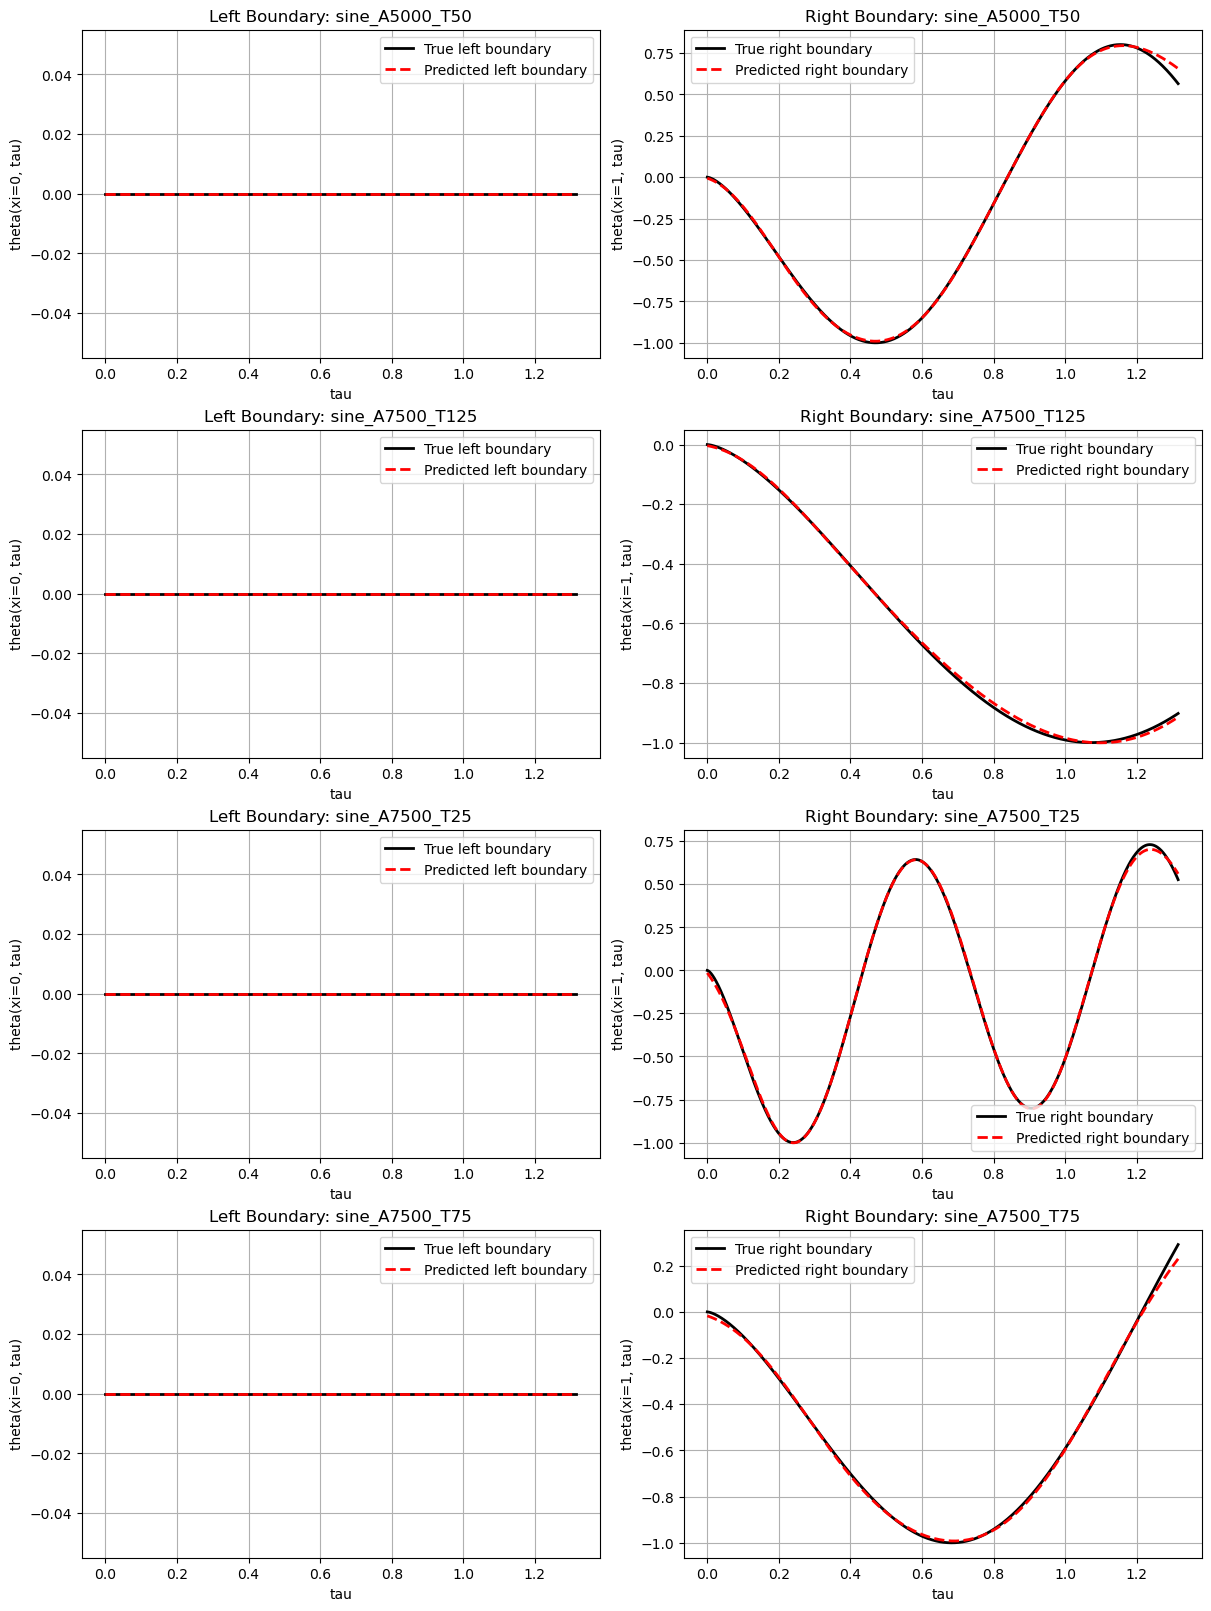

In [22]:

def _phase_lag_tau(y_true, y_pred, tau):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    if y_true.size < 3 or np.allclose(y_true, y_true.mean()):
        return float('nan')
    corr = np.correlate(y_pred - y_pred.mean(), y_true - y_true.mean(), mode='full')
    lag_idx = int(np.argmax(corr) - (y_true.size - 1))
    dtau = float(np.mean(np.diff(tau))) if y_true.size > 1 else float('nan')
    return lag_idx * dtau if np.isfinite(dtau) else float('nan')

def predict_case(model, case, device):
    xi = case["nondim"]["xi"]
    tau = case["nondim"]["tau"]
    theta_true = case["nondim"]["theta"]
    mu_case = case["mu"]

    xi_grid, tau_grid = np.meshgrid(xi, tau, indexing="ij")
    X_pred = np.column_stack([
        xi_grid.reshape(-1),
        tau_grid.reshape(-1),
        np.tile(mu_case, (xi_grid.size, 1)),
    ]).astype(np.float32)

    model.eval()
    with torch.no_grad():
        theta_pred = model(torch.tensor(X_pred, dtype=torch.float32, device=device))
        theta_pred = theta_pred.detach().cpu().numpy().reshape(xi_grid.shape)

    tau_t = torch.tensor(tau.reshape(-1, 1), dtype=torch.float32, device=device)
    xi_right_t = torch.ones_like(tau_t)
    mu_right_t = torch.tensor(np.repeat(mu_case.reshape(1, -1), tau.shape[0], axis=0), dtype=torch.float32, device=device)
    theta_xi_right = dtheta_dxi(model, xi_right_t, tau_t, mu_right_t, create_graph=False).detach().cpu().numpy().reshape(-1)
    aux_flux_pred = None
    if hasattr(model, 'predict_flux'):
        with torch.no_grad():
            aux_flux_pred = model.predict_flux(tau_t, mu_right_t).detach().cpu().numpy().reshape(-1)

    T_left = float(case["physical"]["T_ref"])
    dT = float(case["physical"]["dT_ref"])
    L = float(case["physical"]["L"])
    k = float(case["physical"]["k"])
    flux_scale = k * dT / L
    q_true = case["raw"]["q_right"].reshape(-1)
    q_pred = (-flux_scale * theta_xi_right).reshape(-1)
    amp_true = 0.5 * float(q_true.max() - q_true.min())
    amp_pred = 0.5 * float(q_pred.max() - q_pred.min())
    flux_diff = q_pred - q_true

    T_true = T_left + dT * theta_true
    T_pred = T_left + dT * theta_pred

    return {
        "case_id": case["case_id"],
        "xi": xi,
        "tau": tau,
        "theta_true": theta_true,
        "theta_pred": theta_pred,
        "theta_xi_right": theta_xi_right,
        "aux_flux_pred": aux_flux_pred,
        "q_true": q_true,
        "q_pred": q_pred,
        "T_true": T_true,
        "T_pred": T_pred,
        "left_rmse": float(np.sqrt(np.mean((theta_pred[0, :] - theta_true[0, :]) ** 2))),
        "right_rmse": float(np.sqrt(np.mean((theta_pred[-1, :] - theta_true[-1, :]) ** 2))),
        "full_rmse": float(np.sqrt(np.mean((theta_pred - theta_true) ** 2))),
        "flux_rmse": float(np.sqrt(np.mean(flux_diff ** 2))),
        "flux_rel_l2": float(np.linalg.norm(flux_diff) / (np.linalg.norm(q_true) + 1e-12)),
        "flux_amp_true": amp_true,
        "flux_amp_pred": amp_pred,
        "flux_amp_error": float(abs(amp_pred - amp_true)),
        "phase_lag_tau": float(_phase_lag_tau(q_true, q_pred, tau)),
    }

case_predictions = [predict_case(model, case, device) for case in val_cases]
summary_df = pd.DataFrame([
    {
        "case_id": pred["case_id"],
        "left_rmse": pred["left_rmse"],
        "right_rmse": pred["right_rmse"],
        "full_rmse": pred["full_rmse"],
        "flux_rmse": pred["flux_rmse"],
        "flux_rel_l2": pred["flux_rel_l2"],
        "flux_amp_error": pred["flux_amp_error"],
        "phase_lag_tau": pred["phase_lag_tau"],
    }
    for pred in case_predictions
])
display(summary_df)

fig, axes = plt.subplots(len(case_predictions), 2, figsize=(12, 4 * len(case_predictions)), constrained_layout=True)
if len(case_predictions) == 1:
    axes = np.array([axes])

for row_idx, pred in enumerate(case_predictions):
    tau = pred["tau"]
    theta_true = pred["theta_true"]
    theta_pred = pred["theta_pred"]
    case_id = pred["case_id"]

    ax_left, ax_right = axes[row_idx]

    ax_left.plot(tau, theta_true[0, :], 'k-', linewidth=2, label='True left boundary')
    ax_left.plot(tau, theta_pred[0, :], 'r--', linewidth=2, label='Predicted left boundary')
    ax_left.set_title(f'Left Boundary: {case_id}')
    ax_left.set_xlabel('tau')
    ax_left.set_ylabel('theta(xi=0, tau)')
    ax_left.grid(True)
    ax_left.legend()

    ax_right.plot(tau, theta_true[-1, :], 'k-', linewidth=2, label='True right boundary')
    ax_right.plot(tau, theta_pred[-1, :], 'r--', linewidth=2, label='Predicted right boundary')
    ax_right.set_title(f'Right Boundary: {case_id}')
    ax_right.set_xlabel('tau')
    ax_right.set_ylabel('theta(xi=1, tau)')
    ax_right.grid(True)
    ax_right.legend()

summary_plot_path = OUTDIR / f"heldout_boundary_summary_{case_id}.png"
plt.savefig(summary_plot_path, dpi=150, bbox_inches='tight')
print(f"Saved held-out boundary summary plot to: {summary_plot_path}")
plt.show()


In [ ]:
# Detailed plot for one held-out case
case_idx = 0
pred = case_predictions[case_idx]
case_id = pred["case_id"]
xi = pred["xi"]
tau = pred["tau"]
theta_true = pred["theta_true"]
theta_pred = pred["theta_pred"]
T_true = pred["T_true"]
T_pred = pred["T_pred"]
field_error = T_pred - T_true
q_true = pred["q_true"]
q_pred = pred["q_pred"]

vmin = min(T_true.min(), T_pred.min())
vmax = max(T_true.max(), T_pred.max())
err_lim = np.max(np.abs(field_error))

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

axes[0, 0].plot(tau, theta_true[0, :], 'k-', linewidth=2, label='True')
axes[0, 0].plot(tau, theta_pred[0, :], 'r--', linewidth=2, label='Predicted')
axes[0, 0].set_title(f'Left Boundary Check (Case {case_id})')
axes[0, 0].set_xlabel('tau')
axes[0, 0].set_ylabel('theta(xi=0, tau)')
axes[0, 0].grid(True)
axes[0, 0].legend()

axes[0, 1].plot(tau, theta_true[-1, :], 'k-', linewidth=2, label='True')
axes[0, 1].plot(tau, theta_pred[-1, :], 'r--', linewidth=2, label='Predicted')
axes[0, 1].set_title('Right Boundary Trace')
axes[0, 1].set_xlabel('tau')
axes[0, 1].set_ylabel('theta(xi=1, tau)')
axes[0, 1].grid(True)
axes[0, 1].legend()

axes[0, 2].plot(tau, q_true, 'k-', linewidth=2, label='True flux')
axes[0, 2].plot(tau, q_pred, 'b--', linewidth=2, label='Predicted flux')
axes[0, 2].set_title('Flux Reconstruction')
axes[0, 2].set_xlabel('tau')
axes[0, 2].set_ylabel('q_right')
axes[0, 2].grid(True)
axes[0, 2].legend()

im0 = axes[1, 0].imshow(
    T_true,
    aspect='auto',
    origin='lower',
    extent=[tau.min(), tau.max(), xi.min(), xi.max()],
    vmin=vmin,
    vmax=vmax,
)
axes[1, 0].set_title('Ground Truth Temperature')
axes[1, 0].set_xlabel('tau')
axes[1, 0].set_ylabel('xi')
plt.colorbar(im0, ax=axes[1, 0])

im1 = axes[1, 1].imshow(
    field_error,
    aspect='auto',
    origin='lower',
    extent=[tau.min(), tau.max(), xi.min(), xi.max()],
    cmap='coolwarm',
    vmin=-err_lim,
    vmax=err_lim,
)
axes[1, 1].set_title('Temperature Error (T_pred - T_true)')
axes[1, 1].set_xlabel('tau')
axes[1, 1].set_ylabel('xi')
plt.colorbar(im1, ax=axes[1, 1])

im2 = axes[1, 2].imshow(
    T_pred,
    aspect='auto',
    origin='lower',
    extent=[tau.min(), tau.max(), xi.min(), xi.max()],
    vmin=vmin,
    vmax=vmax,
)
axes[1, 2].set_title('Predicted Temperature')
axes[1, 2].set_xlabel('tau')
axes[1, 2].set_ylabel('xi')
plt.colorbar(im2, ax=axes[1, 2])

detail_plot_path = OUTDIR / f"detailed_case_plot_{case_id}.png"
plt.savefig(detail_plot_path, dpi=150, bbox_inches='tight')
print(f"Saved detailed case plot to: {detail_plot_path}")
print(f"Case RMSE: {pred['full_rmse']:.4e}")
print(f"Flux RMSE: {pred['flux_rmse']:.4e} | Flux rel L2: {pred['flux_rel_l2']:.4e}")
plt.show()


In [ ]:
# Optional: inspect another held-out case by changing `case_idx` in the previous cell.


Loaded checkpoint: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_17_1034\hard_left_bc\2026_03_17_1034_hard_left_bc_best.pt
Validation logs:
  total: 1.1715e-03
  pde: 1.0218e-03
  ic: 1.4398e-05
  bc: 1.1704e-04
  bc_left: 0.0000e+00
  bc_right: 1.1704e-04
  bc_left_raw: 0.0000e+00
  bc_right_raw: 1.1704e-04
  bc_flux_legacy: 0.0000e+00
  bc_left_rmse: 0.0000e+00
  bc_right_rmse: 1.0818e-02
  bc_monitor: 0.0000e+00
  data: 1.8298e-05
  smooth: 0.0000e+00
Validation RMSE (data): 4.2776e-03
Saved validation scatter plot to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_17_1034\validation_scatter.png


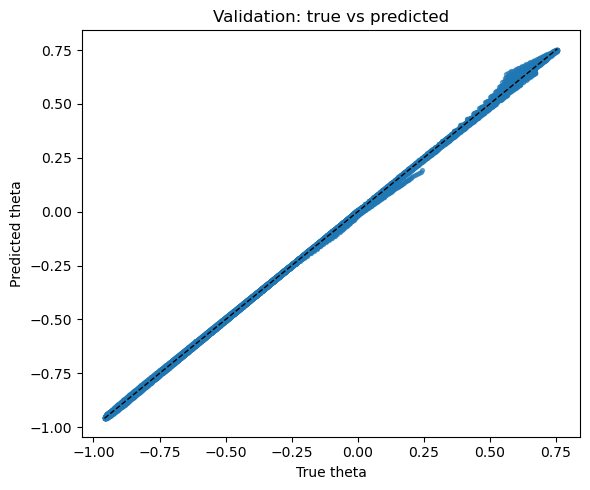

Saved validation metrics to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_17_1034\validation_metrics.txt


In [17]:
# example validation on held-out data
import src.train as train_mod
importlib.reload(train_mod)
from src.train import compute_losses_eval

# load checkpoint
ckpt = best_lbfgs_path if best_lbfgs_path is not None else None
if ckpt is not None and ckpt.exists():
    state = torch.load(ckpt, map_location=device)
    model.load_state_dict(state["state_dict"])
    model.to(device)
    print(f"Loaded checkpoint: {ckpt}")

val_loss, val_logs = compute_losses_eval(model, val_batch, weights, create_graph=False)
print("Validation logs:")
for k, v in val_logs.items():
    print(f"  {k}: {v:.4e}")

if getattr(val_batch, "xi_data", None) is not None:
    model.eval()
    with torch.no_grad():
        X_val = torch.cat([val_batch.xi_data, val_batch.tau_data, val_batch.mu_data], dim=1).to(device)
        y_true = val_batch.theta_data.to(device)
        y_pred = model(X_val)
    mse = torch.mean((y_pred - y_true) ** 2).item()
    rmse = mse ** 0.5
    print(f"Validation RMSE (data): {rmse:.4e}")
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true.cpu().numpy(), y_pred.detach().cpu().numpy(), s=8, alpha=0.6)
    mn = min(y_true.min().item(), y_pred.min().item())
    mx = max(y_true.max().item(), y_pred.max().item())
    plt.plot([mn, mx], [mn, mx], "k--", linewidth=1)
    plt.xlabel("True theta")
    plt.ylabel("Predicted theta")
    plt.title("Validation: true vs predicted")
    plt.tight_layout()
    
    # Save the plot to OUTDIR
    plot_path = OUTDIR / "validation_scatter.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Saved validation scatter plot to: {plot_path}")
    
    plt.show()
else:
    print("No interior validation data present in `val_batch` to plot.")

flux_rmse_mean = float(summary_df["flux_rmse"].mean()) if 'summary_df' in globals() and not summary_df.empty else float('nan')
flux_amp_error_mean = float(summary_df["flux_amp_error"].mean()) if 'summary_df' in globals() and not summary_df.empty else float('nan')
phase_lag_tau_mean = float(summary_df["phase_lag_tau"].dropna().mean()) if 'summary_df' in globals() and summary_df["phase_lag_tau"].notna().any() else float('nan')
print(f"Mean held-out flux RMSE: {flux_rmse_mean:.4e}")
print(f"Mean held-out flux amplitude error: {flux_amp_error_mean:.4e}")
if np.isfinite(phase_lag_tau_mean):
    print(f"Mean held-out phase lag (tau): {phase_lag_tau_mean:.4e}")

# Save validation metrics to OUTDIR
metrics_path = OUTDIR / "validation_metrics.txt"
with open(metrics_path, 'w') as f:
    f.write("Validation Metrics\n")
    f.write("==================\n")
    for k, v in val_logs.items():
        f.write(f"{k}: {v:.6e}\n")
    f.write(f"rmse_data: {rmse:.6e}\n")
    f.write(f"flux_rmse_mean: {flux_rmse_mean:.6e}\n")
    f.write(f"flux_amp_error_mean: {flux_amp_error_mean:.6e}\n")
    f.write(f"phase_lag_tau_mean: {phase_lag_tau_mean:.6e}\n")
print(f"Saved validation metrics to: {metrics_path}")
    

## Upload and update

In [18]:
from src.experiment_logging import append_arch_search_result, compare_arch_to_best, ensure_arch_search_csv, load_best_arch_result
from sklearn.model_selection import train_test_split
import math
import subprocess

In [19]:
# Architecture experiment logger
results_csv = ROOT / "results" / "arch_search.csv"
ensure_arch_search_csv(str(results_csv))
baseline_best = load_best_arch_result(str(results_csv), metric="val_rmse_data")

def _safe_git_commit() -> str:
    try:
        out = subprocess.run(
            ["git", "rev-parse", "--short", "HEAD"],
            cwd=ROOT,
            capture_output=True,
            text=True,
            check=True,
        )
        return out.stdout.strip()
    except Exception:
        return ""

def _first_linear(module):
    for m in module.modules():
        if isinstance(m, torch.nn.Linear):
            return m
    return None

def _activation_name(module):
    for m in module.modules():
        if isinstance(m, (torch.nn.Tanh, torch.nn.ReLU, torch.nn.GELU, torch.nn.Sigmoid, torch.nn.SiLU, torch.nn.ELU, torch.nn.LeakyReLU)):
            return m.__class__.__name__.lower()
    return "unknown"

first_linear = _first_linear(model)
n_neurons = int(first_linear.out_features) if first_linear is not None else None
n_linear = sum(1 for m in model.modules() if isinstance(m, torch.nn.Linear))
n_hidden_layers = max(n_linear - 1, 0)

adam_steps = int(globals().get("N_EPOCHS", globals().get("steps", 1000)))
lbfgs_iters = int(globals().get("max_iter", 500)) if "best_lbfgs_path" in globals() else 0
optimizer_name = "adam+lbfgs" if "best_lbfgs_path" in globals() else "adam"

current_result = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "git_commit": _safe_git_commit(),
    "seed": 42,
    "n_layers": n_hidden_layers,
    "n_neurons": n_neurons,
    "activation": _activation_name(model),
    "optimizer": optimizer_name,
    "epochs": adam_steps + lbfgs_iters,
    "lr": 1e-3,
    "n_colloc": int(globals().get("n_r", 50000)),
    "n_boundary": int(getattr(train_batch, "xi_bc", torch.empty(0, 1)).shape[0]),
    "n_initial": int(getattr(train_batch, "xi_ic", torch.empty(0, 1)).shape[0]),
    "n_data": int(getattr(train_batch, "xi_data", torch.empty(0, 1)).shape[0]),
    "loss_total": float(val_logs.get("total", math.nan)),
    "loss_pde": float(val_logs.get("pde", math.nan)),
    "loss_ic": float(val_logs.get("ic", math.nan)),
    "loss_bc": float(val_logs.get("bc", math.nan)),
    "loss_data": float(val_logs.get("data", math.nan)),
    "val_rmse_data": float(rmse),
    "val_pde_loss": float(val_logs.get("pde", math.nan)),
}

improved, reason = compare_arch_to_best(current_result, baseline_best)
append_arch_search_result(str(results_csv), current_result)

def _fmt(x):
    try:
        v = float(x)
        if math.isfinite(v):
            return f"{v:.6e}"
    except Exception:
        pass
    return "nan"

print()
print("Architecture comparison:")
if baseline_best is None:
    print("Baseline best metrics: none (first recorded run)")
else:
    print(
        "Baseline best metrics: "
        f"val_rmse_data={_fmt(baseline_best.get('val_rmse_data'))}, "
        f"val_pde_loss={_fmt(baseline_best.get('val_pde_loss'))}, "
        f"loss_total={_fmt(baseline_best.get('loss_total'))}"
    )

print(
    "Current metrics: "
    f"val_rmse_data={_fmt(current_result.get('val_rmse_data'))}, "
    f"val_pde_loss={_fmt(current_result.get('val_pde_loss'))}, "
    f"loss_total={_fmt(current_result.get('loss_total'))}"
)
print(("? IMPROVED: " if improved else "? NOT IMPROVED: ") + reason)
print(f"Logged run to {results_csv}")




Architecture comparison:
Baseline best metrics: val_rmse_data=2.939769e-03, val_pde_loss=4.508330e-05, loss_total=8.602647e-05
Current metrics: val_rmse_data=4.277628e-03, val_pde_loss=1.021791e-03, loss_total=1.171525e-03
? NOT IMPROVED: RMSE gain -1.337859e-03 is below threshold 1.000000e-04.
Logged run to c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\results\arch_search.csv


In [20]:
log_path = Path(ROOT, "results", "experiment_log.csv")
if log_path.exists():
    log_df = pd.read_csv(log_path)
    display(log_df.tail(5))
else:
    print(f"No log found at {log_path}")

,experiment_id,date_time_utc,commit_hash,python_version,torch_version,cuda_available,device,random_seed,case_id,data_paths,...,final_total_loss,final_pde_loss,final_bc_loss,final_ic_loss,final_data_loss,final_grad_norm,l2_error_temperature,max_abs_error,relative_l2_error,r2_score
0,20260216T153205Z_const_5000_596ff96_19ff91,2026-02-16T15:32:05.004343+00:00,596ff96,3.10.9,1.12.1,False,cpu,42,const_5000,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.001084,0.000171,0.000001,0.000576,0.000336,NaN,NaN,NaN,NaN,NaN
1,20260216T161524Z_const_5000_775133c_437d6a,2026-02-16T16:15:24.247973+00:00,775133c,3.10.9,1.12.1,False,cpu,42,const_5000,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.002162,0.000349,0.000325,0.001451,0.000037,NaN,NaN,NaN,NaN,NaN
2,20260309T145841Z_sine_A10000_T50_unknown_7eaa2a,2026-03-09T14:58:41.916964+00:00,unknown,3.10.9,1.12.1,False,cpu,42,sine_A10000_T50,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.002085,0.001231,0.000432,0.000148,0.000275,NaN,NaN,NaN,NaN,NaN
3,20260309T145841Z_sine_A10000_T50_unknown_7eaa2a,2026-03-09T14:58:41.916964+00:00,unknown,3.10.9,1.12.1,False,cpu,42,sine_A10000_T50,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.002085,0.001231,0.000432,0.000148,0.000275,NaN,NaN,NaN,NaN,NaN
